In [1]:
from pathlib import Path
from collections import Counter
import time

import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR = PROJECT_ROOT / "report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

SR = 22050
WINDOW_SAMPLES = 11025

# PyTorch device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load prepared audio + metadata
X_audio = np.load(PROCESSED_DIR / "windows_audio.npy")
metadata_df = pd.read_parquet(PROCESSED_DIR / "windows_metadata.parquet")

NUM_CLASSES = int(metadata_df["class_id"].max()) + 1

print(f"\nAudio: {X_audio.shape}")
print(f"Metadata: {metadata_df.shape}")
print(f"Num classes: {NUM_CLASSES}")

PyTorch: 2.13.0+cpu
Device: cpu

Audio: (19983, 11025)
Metadata: (19983, 5)
Num classes: 37


In [2]:
# CQT parameters — same as we used in notebook 01 for the plot
N_BINS = 84             # 7 octaves × 12 semitones
BINS_PER_OCTAVE = 12
HOP_LENGTH = 512        # frames per second = SR / HOP_LENGTH = ~43
# For a 500ms window at 22050 Hz with hop=512, we get ~22 time frames

def audio_to_cqt(audio: np.ndarray, sr: int = SR) -> np.ndarray:
    """
    Convert a 500ms audio window to a log-magnitude CQT spectrogram.
    Returns shape (N_BINS, T) where T is the number of time frames.
    """
    C = np.abs(librosa.cqt(
        audio,
        sr=sr,
        hop_length=HOP_LENGTH,
        n_bins=N_BINS,
        bins_per_octave=BINS_PER_OCTAVE,
    ))
    # Log-magnitude — critical for CNN. Raw magnitude has huge dynamic range.
    C_db = librosa.amplitude_to_db(C, ref=np.max)
    return C_db.astype(np.float32)


# Test on window 0
test_cqt = audio_to_cqt(X_audio[0])
print(f"CQT shape: {test_cqt.shape}")   # expect (84, ~22)
print(f"CQT dtype: {test_cqt.dtype}")
print(f"CQT value range: [{test_cqt.min():.2f}, {test_cqt.max():.2f}] dB")
print(f"Time frames: {test_cqt.shape[1]}")

CQT shape: (84, 22)
CQT dtype: float32
CQT value range: [-80.00, 0.00] dB
Time frames: 22


c:\Users\Constantine\Code\ml-project\.venv\Lib\site-packages\librosa\core\constantq.py:1202: UserWarning: n_fft=256 is too large for input signal of length=173
  D = stft(


In [3]:
print(f"Computing CQT for {len(X_audio)} windows...")
start = time.time()

# Do the first one to get the exact time-frame count
test_cqt = audio_to_cqt(X_audio[0])
n_frames = test_cqt.shape[1]

X_cqt = np.zeros((len(X_audio), N_BINS, n_frames), dtype=np.float32)
X_cqt[0] = test_cqt
for i in tqdm(range(1, len(X_audio)), desc="CQT"):
    X_cqt[i] = audio_to_cqt(X_audio[i])

elapsed = time.time() - start
print(f"\nDone in {elapsed:.1f}s")
print(f"X_cqt shape: {X_cqt.shape}, dtype: {X_cqt.dtype}")
print(f"Size in memory: {X_cqt.nbytes / 1e6:.1f} MB")

# Save so we never have to compute again
cqt_path = PROCESSED_DIR / "windows_cqt.npy"
np.save(cqt_path, X_cqt)
print(f"Saved to {cqt_path} ({cqt_path.stat().st_size / 1e6:.1f} MB)")

Computing CQT for 19983 windows...


CQT: 100%|██████████| 19982/19982 [06:30<00:00, 51.12it/s]



Done in 390.9s
X_cqt shape: (19983, 84, 22), dtype: float32
Size in memory: 147.7 MB
Saved to c:\Users\Constantine\Code\ml-project\data\processed\windows_cqt.npy (147.7 MB)


In [4]:
class ChordDataset(Dataset):
    """
    Serves (CQT_spectrogram, class_id) pairs for a specific split.
    CQT tensor gets a leading channel dimension: (1, N_BINS, T)
    """
    def __init__(self, X_cqt: np.ndarray, y: np.ndarray):
        # Normalize globally: shift from [-80, 0] dB to roughly [0, 1]
        # Simple, deterministic, no train/test leakage risk
        X_normalized = (X_cqt + 80.0) / 80.0
        self.X = torch.from_numpy(X_normalized).unsqueeze(1).contiguous()  # (N, 1, 84, 22)
        self.y = torch.from_numpy(y).long()

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]


# Build train / val / test datasets from the split column
train_mask = (metadata_df["split"] == "train").to_numpy()
val_mask = (metadata_df["split"] == "val").to_numpy()
test_mask = (metadata_df["split"] == "test").to_numpy()

y_all = metadata_df["class_id"].to_numpy()

train_ds = ChordDataset(X_cqt[train_mask], y_all[train_mask])
val_ds = ChordDataset(X_cqt[val_mask], y_all[val_mask])
test_ds = ChordDataset(X_cqt[test_mask], y_all[test_mask])

print(f"Train dataset: {len(train_ds)}")
print(f"Val dataset:   {len(val_ds)}")
print(f"Test dataset:  {len(test_ds)}")

# One sample to confirm shape
x0, y0 = train_ds[0]
print(f"\nSample shape: {tuple(x0.shape)} — expect (1, 84, 22)")
print(f"Sample dtype: {x0.dtype}")
print(f"Sample range: [{x0.min():.3f}, {x0.max():.3f}]")
print(f"Label: {y0.item()}")

Train dataset: 12964
Val dataset:   3513
Test dataset:  3506

Sample shape: (1, 84, 22) — expect (1, 84, 22)
Sample dtype: torch.float32
Sample range: [0.000, 1.000]
Label: 15


In [5]:
class ChordCNN(nn.Module):
    """
    3-block 2D CNN for CQT chord/note classification.
    Input:  (batch, 1, 84 pitch bins, 22 time frames)
    Output: (batch, num_classes) logits
    """
    def __init__(self, num_classes: int, dropout: float = 0.3):
        super().__init__()

        # Block 1: 1 → 32 channels, halve pitch axis
        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 1))   # halve pitch, keep time

        # Block 2: 32 → 64, halve pitch again
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2))   # halve both axes

        # Block 3: 64 → 128, halve pitch again
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=(2, 2))

        # Global average pool → dense head
        self.global_pool = nn.AdaptiveAvgPool2d(1)      # (B, 128, 1, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.global_pool(x).flatten(1)              # (B, 128)
        x = self.dropout(x)
        return self.fc(x)


# Instantiate and check parameter count + shape flow
model = ChordCNN(num_classes=NUM_CLASSES).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameter count: {n_params:,}")

# Forward pass with a dummy batch to confirm shapes
dummy_x, _ = train_ds[0]
dummy_batch = dummy_x.unsqueeze(0).to(DEVICE)  # (1, 1, 84, 22)
with torch.no_grad():
    dummy_out = model(dummy_batch)
print(f"Input shape:  {tuple(dummy_batch.shape)}")
print(f"Output shape: {tuple(dummy_out.shape)} — expect (1, {NUM_CLASSES})")

Model parameter count: 97,893
Input shape:  (1, 1, 84, 22)
Output shape: (1, 37) — expect (1, 37)


In [6]:
from sklearn.utils.class_weight import compute_class_weight

y_train_np = y_all[train_mask]
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train_np,
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)

print(f"Class weights range: [{class_weights.min().item():.3f}, {class_weights.max().item():.3f}]")
print(f"Most-weighted class (rarest): {int(class_weights.argmax().item())}")
print(f"Least-weighted class (most common): {int(class_weights.argmin().item())}")

Class weights range: [0.310, 7.617]
Most-weighted class (rarest): 9
Least-weighted class (most common): 13


In [7]:
import matplotlib.pyplot as plt

# Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5  # early stopping — stop if val doesn't improve for this many epochs

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Re-init model so training is reproducible
torch.manual_seed(SEED)
model = ChordCNN(num_classes=NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [],
    "lr": [],
}

best_val_acc = 0.0
best_epoch = 0
epochs_without_improve = 0

model_path = MODELS_DIR / "cnn_best.pt"

print(f"Training on {DEVICE}, {NUM_EPOCHS} epochs, batch size {BATCH_SIZE}\n")

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # --- Train ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for x_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch:2d}/{NUM_EPOCHS} train", leave=False):
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)
        correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total += x_batch.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # --- Val ---
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            running_loss += loss.item() * x_batch.size(0)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total += x_batch.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    elapsed = time.time() - epoch_start
    improved = val_acc > best_val_acc
    marker = "  ← best" if improved else ""

    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} acc={train_acc:.3f} | "
        f"val_loss={val_loss:.4f} acc={val_acc:.3f} | "
        f"lr={current_lr:.1e} | {elapsed:.1f}s{marker}"
    )

    if improved:
        best_val_acc = val_acc
        best_epoch = epoch
        epochs_without_improve = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_acc": val_acc,
            "num_classes": NUM_CLASSES,
        }, model_path)
    else:
        epochs_without_improve += 1
        if epochs_without_improve >= PATIENCE:
            print(f"\nEarly stopping — no improvement for {PATIENCE} epochs.")
            break

print(f"\n{'='*60}")
print(f"Best val accuracy: {best_val_acc:.3f} at epoch {best_epoch}")
print(f"Model saved to {model_path}")
print(f"{'='*60}")

Training on cpu, 20 epochs, batch size 64



Epoch  1/20 | train_loss=3.0158 acc=0.150 | val_loss=2.4241 acc=0.284 | lr=1.0e-03 | 30.9s  ← best


Epoch  2/20 | train_loss=2.0789 acc=0.348 | val_loss=2.0661 acc=0.333 | lr=1.0e-03 | 29.7s  ← best


Epoch  3/20 | train_loss=1.7505 acc=0.432 | val_loss=1.9316 acc=0.364 | lr=1.0e-03 | 30.1s  ← best


Epoch  4/20 | train_loss=1.5940 acc=0.475 | val_loss=1.8910 acc=0.358 | lr=1.0e-03 | 30.6s


...

Epoch 16/20 | train_loss=0.8194 acc=0.677 | val_loss=1.3811 acc=0.531 | lr=5.0e-04 | 31.3s


Epoch 17/20 | train_loss=0.8184 acc=0.676 | val_loss=1.2311 acc=0.590 | lr=5.0e-04 | 28.8s  ← best


Epoch 18/20 | train_loss=0.7982 acc=0.678 | val_loss=1.4156 acc=0.516 | lr=5.0e-04 | 28.9s


Epoch 19/20 | train_loss=0.7993 acc=0.678 | val_loss=1.2310 acc=0.601 | lr=5.0e-04 | 28.5s  ← best


Epoch 20/20 | train_loss=0.7797 acc=0.691 | val_loss=1.3866 acc=0.531 | lr=5.0e-04 | 29.3s

Best val accuracy: 0.601 at epoch 19
Model saved to c:\Users\Constantine\Code\ml-project\models\cnn_best.pt


In [8]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, precision_recall_fscore_support,
)

# Load best checkpoint
checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded checkpoint from epoch {checkpoint['epoch']} — val_acc {checkpoint['val_acc']:.3f}")


def predict_split(dataset: ChordDataset) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Run model on a dataset, return (y_true, y_pred, y_proba)."""
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
    y_true_list, y_pred_list, y_proba_list = [], [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            logits = model(x_batch)
            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)
            y_true_list.append(y_batch.numpy())
            y_pred_list.append(preds.cpu().numpy())
            y_proba_list.append(probs.cpu().numpy())
    return (
        np.concatenate(y_true_list),
        np.concatenate(y_pred_list),
        np.concatenate(y_proba_list),
    )

y_val_true, y_val_pred, y_val_proba = predict_split(val_ds)
y_test_true, y_test_pred, y_test_proba = predict_split(test_ds)

print(f"\nVal  accuracy: {accuracy_score(y_val_true, y_val_pred):.3f}")
print(f"Test accuracy: {accuracy_score(y_test_true, y_test_pred):.3f}")

Loaded checkpoint from epoch 19 — val_acc 0.601

Val  accuracy: 0.601
Test accuracy: 0.573


In [9]:
id_to_name = dict(zip(metadata_df["class_id"], metadata_df["class_name"]))
target_names = [id_to_name[i] for i in sorted(id_to_name.keys())]

print("CNN — Classification report on VALIDATION set:\n")
print(classification_report(
    y_val_true, y_val_pred,
    target_names=target_names, digits=3, zero_division=0,
))

CNN — Classification report on VALIDATION set:

              precision    recall  f1-score   support

      note:C      0.643     0.409     0.500        22
     note:C#      0.633     0.816     0.713        38
      note:D      1.000     0.767     0.868        43
     note:D#      0.638     0.881     0.740        42
      note:E      0.347     1.000     0.515        35
      note:F      0.651     0.875     0.747        32
     note:F#      0.714     0.854     0.778        41
      note:G      0.800     0.846     0.822        52
     note:G#      0.917     0.373     0.530        59
      note:A      1.000     0.435     0.606        23
     note:A#      0.740     0.902     0.813        41
      note:B      0.778     0.259     0.389        27
       maj:C      0.656     0.577     0.614       222
      maj:C#      0.782     0.304     0.438       283
       maj:D      0.580     0.545     0.562       167
      maj:D#      0.955     0.740     0.834       227
       maj:E      0.683     0.716

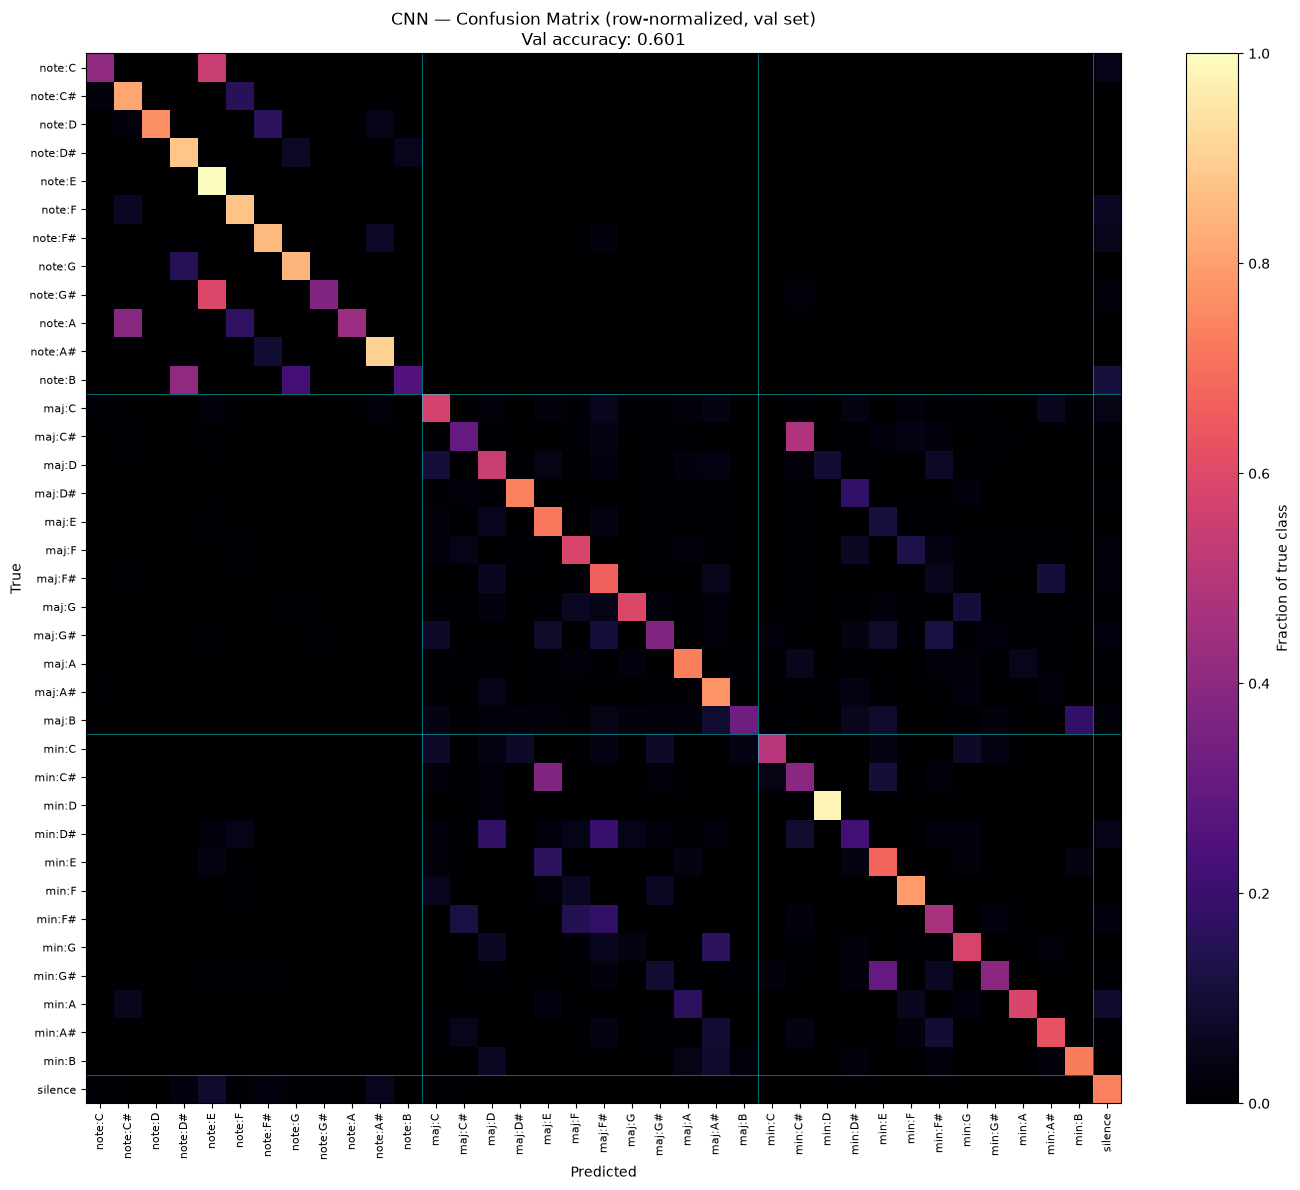

Saved to c:\Users\Constantine\Code\ml-project\report\cnn_confusion_matrix.png


In [10]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val_true, y_val_pred, labels=list(range(NUM_CLASSES)))
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_norm, cmap="magma", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(target_names, rotation=90, fontsize=8)
ax.set_yticklabels(target_names, fontsize=8)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"CNN — Confusion Matrix (row-normalized, val set)\n"
             f"Val accuracy: {accuracy_score(y_val_true, y_val_pred):.3f}")

for boundary in [11.5, 23.5, 35.5]:
    ax.axhline(boundary, color="cyan", linewidth=0.5, alpha=0.6)
    ax.axvline(boundary, color="cyan", linewidth=0.5, alpha=0.6)

fig.colorbar(im, ax=ax, label="Fraction of true class")
plt.tight_layout()
fig.savefig(REPORT_DIR / "cnn_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved to {REPORT_DIR / 'cnn_confusion_matrix.png'}")

In [11]:
# Recompute RF predictions on val — need them in this notebook
from sklearn.ensemble import RandomForestClassifier

X_features = np.load(PROCESSED_DIR / "windows_features_classical.npy")
X_val_feat = X_features[val_mask]
y_val_feat = y_all[val_mask]

# Re-train RF quickly (~5s) to be self-contained here
rf = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=2, class_weight="balanced",
    n_jobs=-1, random_state=42,
)
X_train_feat = X_features[train_mask]
y_train_feat = y_all[train_mask]
rf.fit(X_train_feat, y_train_feat)
y_val_pred_rf = rf.predict(X_val_feat)

# Per-class F1 comparison
_, _, rf_f1, _ = precision_recall_fscore_support(
    y_val_feat, y_val_pred_rf, labels=range(NUM_CLASSES), zero_division=0
)
_, _, cnn_f1, _ = precision_recall_fscore_support(
    y_val_true, y_val_pred, labels=range(NUM_CLASSES), zero_division=0
)

# Group by class type
groups = {
    "Notes (0-11)":         (0, 12),
    "Major triads (12-23)": (12, 24),
    "Minor triads (24-35)": (24, 36),
    "Silence (36)":         (36, 37),
}

print(f"\n{'Category':<24} {'RF F1':>10} {'CNN F1':>10} {'Δ':>10}")
print("-" * 56)
for name, (a, b) in groups.items():
    rf_mean = rf_f1[a:b].mean()
    cnn_mean = cnn_f1[a:b].mean()
    delta = cnn_mean - rf_mean
    marker = " ←" if abs(delta) > 0.05 else ""
    print(f"{name:<24} {rf_mean:>10.3f} {cnn_mean:>10.3f} {delta:>+10.3f}{marker}")

overall_rf = accuracy_score(y_val_feat, y_val_pred_rf)
overall_cnn = accuracy_score(y_val_true, y_val_pred)
print("-" * 56)
print(f"{'Overall accuracy':<24} {overall_rf:>10.3f} {overall_cnn:>10.3f} {overall_cnn - overall_rf:>+10.3f}")


Category                      RF F1     CNN F1          Δ
--------------------------------------------------------
Notes (0-11)                  0.895      0.668     -0.227 ←
Major triads (12-23)          0.524      0.626     +0.102 ←
Minor triads (24-35)          0.363      0.494     +0.130 ←
Silence (36)                  0.700      0.613     -0.087 ←
--------------------------------------------------------
Overall accuracy              0.573      0.601     +0.028


In [12]:
def shift_label(class_id: int, semitones: int) -> int:
    """
    Return the class ID after shifting the audio by `semitones`.
    Silence (class 36) is invariant. Notes/majors/minors wrap within their 12-class group.
    """
    if class_id == 36:  # silence
        return 36
    group = class_id // 12          # 0=notes, 1=major, 2=minor
    pitch_in_group = class_id % 12
    new_pitch = (pitch_in_group + semitones) % 12
    return group * 12 + new_pitch


def shift_cqt(cqt: np.ndarray, semitones: int) -> np.ndarray:
    """
    Shift the CQT along the pitch axis by `semitones` bins.
    Positive = up (higher pitch), negative = down.
    Bins that fall off the edge are replaced with the minimum value (silence).
    """
    result = np.full_like(cqt, cqt.min())
    if semitones == 0:
        return cqt.copy()
    if semitones > 0:
        result[semitones:, :] = cqt[:-semitones, :]
    else:
        result[:semitones, :] = cqt[-semitones:, :]
    return result


# Sanity check
test_idx = 0
original_cqt = X_cqt[test_idx]
original_label = y_all[test_idx]
shifted_cqt = shift_cqt(original_cqt, 3)
shifted_label = shift_label(int(original_label), 3)
print(f"Original: class {original_label} ({id_to_name[int(original_label)]})")
print(f"Shifted +3 semitones: class {shifted_label} ({id_to_name[shifted_label]})")
print(f"CQT shapes match: {original_cqt.shape == shifted_cqt.shape}")

# Build augmented training set
SHIFTS = [-3, -2, -1, 0, 1, 2, 3]  # 7 versions of each example
train_cqt = X_cqt[train_mask]
train_labels = y_all[train_mask]

n_train = len(train_cqt)
n_aug = n_train * len(SHIFTS)
print(f"\nBuilding augmented training set: {n_train} × {len(SHIFTS)} = {n_aug} examples")

X_train_aug = np.zeros((n_aug, N_BINS, n_frames), dtype=np.float32)
y_train_aug = np.zeros(n_aug, dtype=np.int64)

idx = 0
for shift in tqdm(SHIFTS, desc="Shifts"):
    for i in range(n_train):
        X_train_aug[idx] = shift_cqt(train_cqt[i], shift)
        y_train_aug[idx] = shift_label(int(train_labels[i]), shift)
        idx += 1

print(f"\nAugmented shape: {X_train_aug.shape}")
print(f"Memory: {X_train_aug.nbytes / 1e6:.0f} MB")

# New class distribution
aug_counts = Counter(y_train_aug.tolist())
print(f"\nClass balance after augmentation:")
print(f"  Min class count: {min(aug_counts.values())}")
print(f"  Max class count: {max(aug_counts.values())}")
print(f"  Range: {max(aug_counts.values()) / min(aug_counts.values()):.1f}x  (was ~25x before)")

Original: class 15 (maj:D#)
Shifted +3 semitones: class 18 (maj:F#)
CQT shapes match: True

Building augmented training set: 12964 × 7 = 90748 examples


Shifts: 100%|██████████| 7/7 [00:00<00:00, 10.76it/s]


Augmented shape: (90748, 84, 22)
Memory: 671 MB

Class balance after augmentation:
  Min class count: 477
  Max class count: 6032
  Range: 12.6x  (was ~25x before)


In [13]:
# --- Build augmented training dataset ---
class AugmentedCQTDataset(Dataset):
    """Serves pre-augmented CQT tensors + labels."""
    def __init__(self, X_cqt: np.ndarray, y: np.ndarray):
        X_normalized = (X_cqt + 80.0) / 80.0
        self.X = torch.from_numpy(X_normalized).unsqueeze(1).contiguous()
        self.y = torch.from_numpy(y).long()

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]


train_ds_aug = AugmentedCQTDataset(X_train_aug, y_train_aug)
# val_ds and test_ds stay the same — never augment those

# Recompute class weights on the augmented distribution
class_weights_aug_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train_aug,
)
class_weights_aug = torch.tensor(class_weights_aug_np, dtype=torch.float32).to(DEVICE)
print(f"Augmented class weights range: "
      f"[{class_weights_aug.min().item():.3f}, {class_weights_aug.max().item():.3f}]")

# --- Training hyperparameters (adjusted for more data) ---
BATCH_SIZE_AUG = 128
NUM_EPOCHS_AUG = 12  # fewer epochs since each covers 7x more examples
LEARNING_RATE_AUG = 1e-3
WEIGHT_DECAY_AUG = 1e-4
PATIENCE_AUG = 4

train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE_AUG,
                              shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE_AUG, shuffle=False)

# Fresh model — no fine-tuning, from scratch
torch.manual_seed(SEED)
model_aug = ChordCNN(num_classes=NUM_CLASSES).to(DEVICE)

criterion_aug = nn.CrossEntropyLoss(weight=class_weights_aug)
optimizer_aug = torch.optim.Adam(model_aug.parameters(),
                                 lr=LEARNING_RATE_AUG, weight_decay=WEIGHT_DECAY_AUG)
scheduler_aug = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_aug, mode="max", factor=0.5, patience=2
)

history_aug = {"train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": [], "lr": []}
best_val_acc_aug = 0.0
best_epoch_aug = 0
epochs_without_improve_aug = 0

model_aug_path = MODELS_DIR / "cnn_augmented_best.pt"

print(f"\nTraining with augmentation, {NUM_EPOCHS_AUG} epochs, batch size {BATCH_SIZE_AUG}")
print(f"Training samples per epoch: {len(train_ds_aug):,}\n")

for epoch in range(1, NUM_EPOCHS_AUG + 1):
    epoch_start = time.time()

    # Train
    model_aug.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for x_batch, y_batch in tqdm(train_loader_aug,
                                 desc=f"Epoch {epoch:2d}/{NUM_EPOCHS_AUG} train",
                                 leave=False):
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer_aug.zero_grad()
        logits = model_aug(x_batch)
        loss = criterion_aug(logits, y_batch)
        loss.backward()
        optimizer_aug.step()
        running_loss += loss.item() * x_batch.size(0)
        correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total += x_batch.size(0)
    train_loss = running_loss / total
    train_acc = correct / total

    # Val
    model_aug.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = model_aug(x_batch)
            loss = criterion_aug(logits, y_batch)
            running_loss += loss.item() * x_batch.size(0)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total += x_batch.size(0)
    val_loss = running_loss / total
    val_acc = correct / total

    scheduler_aug.step(val_acc)
    current_lr = optimizer_aug.param_groups[0]["lr"]

    history_aug["train_loss"].append(train_loss)
    history_aug["train_acc"].append(train_acc)
    history_aug["val_loss"].append(val_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["lr"].append(current_lr)

    elapsed = time.time() - epoch_start
    improved = val_acc > best_val_acc_aug
    marker = "  ← best" if improved else ""

    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS_AUG} | "
        f"train_loss={train_loss:.4f} acc={train_acc:.3f} | "
        f"val_loss={val_loss:.4f} acc={val_acc:.3f} | "
        f"lr={current_lr:.1e} | {elapsed:.1f}s{marker}"
    )

    if improved:
        best_val_acc_aug = val_acc
        best_epoch_aug = epoch
        epochs_without_improve_aug = 0
        torch.save({
            "model_state_dict": model_aug.state_dict(),
            "epoch": epoch,
            "val_acc": val_acc,
            "num_classes": NUM_CLASSES,
        }, model_aug_path)
    else:
        epochs_without_improve_aug += 1
        if epochs_without_improve_aug >= PATIENCE_AUG:
            print(f"\nEarly stopping — no improvement for {PATIENCE_AUG} epochs.")
            break

print(f"\n{'='*60}")
print(f"Best AUG val accuracy: {best_val_acc_aug:.3f} at epoch {best_epoch_aug}")
print(f"Model saved to {model_aug_path}")
print(f"{'='*60}")

Augmented class weights range: [0.407, 5.142]

Training with augmentation, 12 epochs, batch size 128
Training samples per epoch: 90,748



Epoch  1/12 | train_loss=2.2023 acc=0.226 | val_loss=1.9720 acc=0.333 | lr=1.0e-03 | 184.0s  ← best


Epoch  2/12 | train_loss=1.7323 acc=0.329 | val_loss=1.6850 acc=0.415 | lr=1.0e-03 | 161.6s  ← best


Epoch  3/12 | train_loss=1.6123 acc=0.379 | val_loss=1.6292 acc=0.431 | lr=1.0e-03 | 168.3s  ← best


Epoch  4/12 | train_loss=1.5216 acc=0.415 | val_loss=1.5563 acc=0.503 | lr=1.0e-03 | 174.5s  ← best


...

Epoch  8/12 | train_loss=1.2622 acc=0.507 | val_loss=1.5677 acc=0.494 | lr=1.0e-03 | 169.2s


Epoch  9/12 | train_loss=1.2097 acc=0.524 | val_loss=1.3153 acc=0.525 | lr=5.0e-04 | 171.9s


Epoch 10/12 | train_loss=1.1397 acc=0.544 | val_loss=1.0971 acc=0.623 | lr=5.0e-04 | 174.5s  ← best


Epoch 11/12 | train_loss=1.1093 acc=0.554 | val_loss=1.0738 acc=0.645 | lr=5.0e-04 | 174.5s  ← best


Epoch 12/12 | train_loss=1.0827 acc=0.563 | val_loss=1.0791 acc=0.606 | lr=5.0e-04 | 181.5s

Best AUG val accuracy: 0.645 at epoch 11
Model saved to c:\Users\Constantine\Code\ml-project\models\cnn_augmented_best.pt


In [14]:
# Load augmented model
checkpoint_aug = torch.load(model_aug_path, map_location=DEVICE, weights_only=True)
model_aug.load_state_dict(checkpoint_aug["model_state_dict"])
model_aug.eval()
print(f"Loaded augmented model from epoch {checkpoint_aug['epoch']} — val_acc {checkpoint_aug['val_acc']:.3f}")


def predict_with(model_to_use: nn.Module, dataset: ChordDataset) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
    y_true_list, y_pred_list, y_proba_list = [], [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            logits = model_to_use(x_batch)
            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)
            y_true_list.append(y_batch.numpy())
            y_pred_list.append(preds.cpu().numpy())
            y_proba_list.append(probs.cpu().numpy())
    return (
        np.concatenate(y_true_list),
        np.concatenate(y_pred_list),
        np.concatenate(y_proba_list),
    )


y_val_true_aug, y_val_pred_aug, y_val_proba_aug = predict_with(model_aug, val_ds)
y_test_true_aug, y_test_pred_aug, y_test_proba_aug = predict_with(model_aug, test_ds)

print(f"\nAugmented CNN — Val  accuracy: {accuracy_score(y_val_true_aug, y_val_pred_aug):.3f}")
print(f"Augmented CNN — Test accuracy: {accuracy_score(y_test_true_aug, y_test_pred_aug):.3f}")

Loaded augmented model from epoch 11 — val_acc 0.645

Augmented CNN — Val  accuracy: 0.645
Augmented CNN — Test accuracy: 0.633


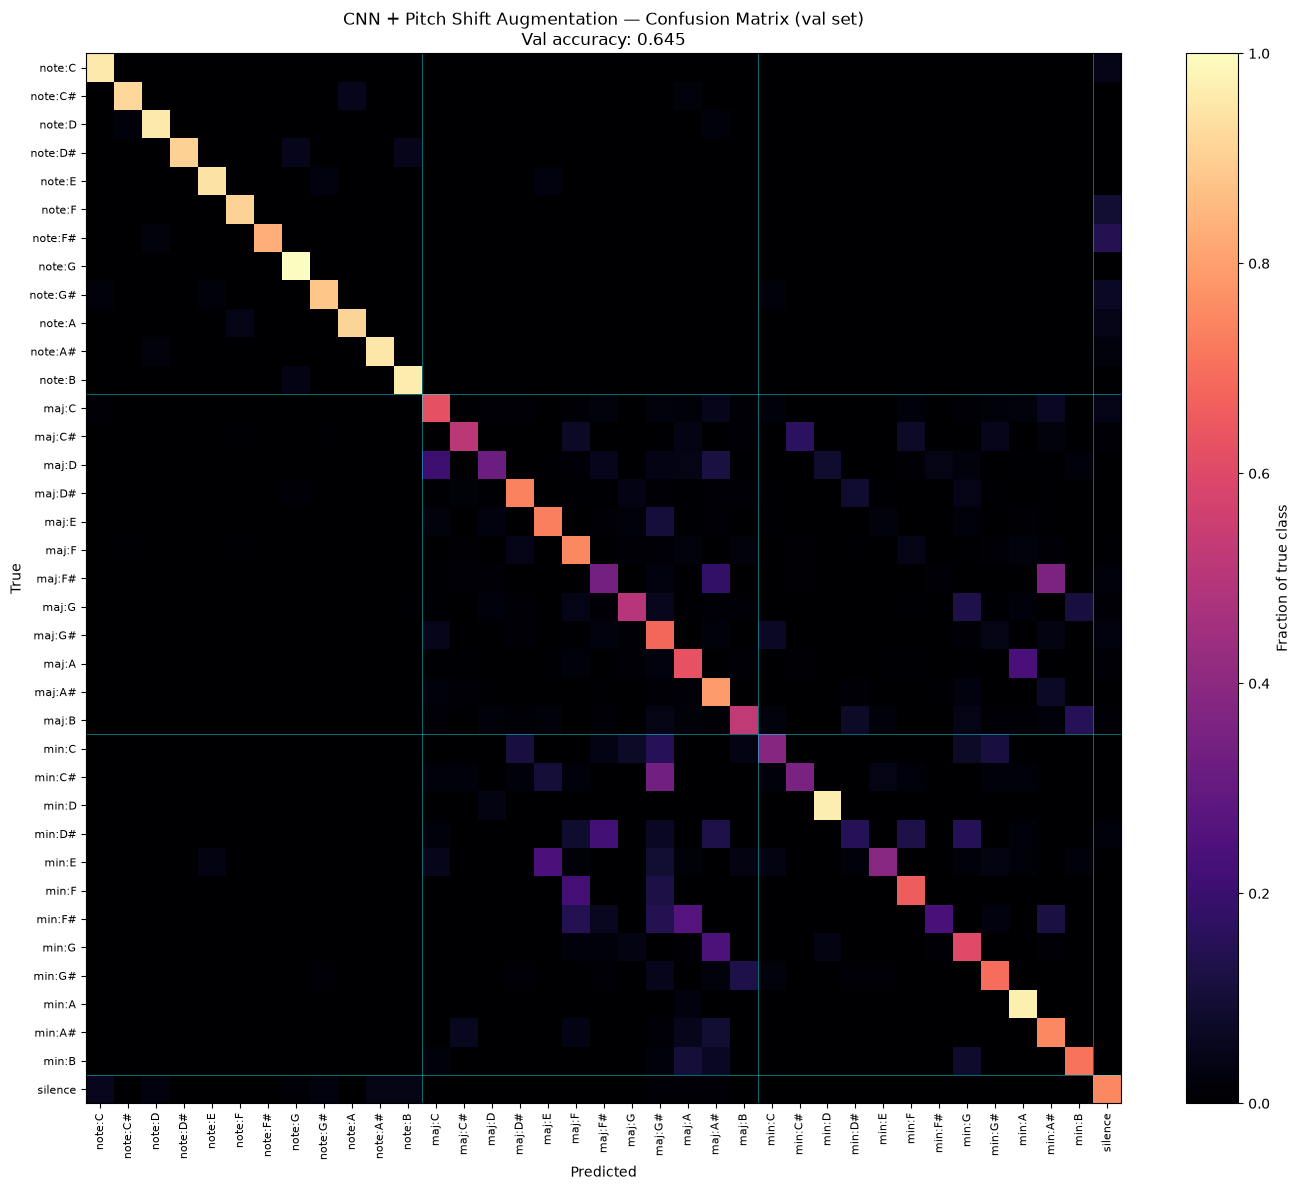

Saved to c:\Users\Constantine\Code\ml-project\report\cnn_augmented_confusion_matrix.png


In [15]:
cm = confusion_matrix(y_val_true_aug, y_val_pred_aug, labels=list(range(NUM_CLASSES)))
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_norm, cmap="magma", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(target_names, rotation=90, fontsize=8)
ax.set_yticklabels(target_names, fontsize=8)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"CNN + Pitch Shift Augmentation — Confusion Matrix (val set)\n"
             f"Val accuracy: {accuracy_score(y_val_true_aug, y_val_pred_aug):.3f}")

for boundary in [11.5, 23.5, 35.5]:
    ax.axhline(boundary, color="cyan", linewidth=0.5, alpha=0.6)
    ax.axvline(boundary, color="cyan", linewidth=0.5, alpha=0.6)

fig.colorbar(im, ax=ax, label="Fraction of true class")
plt.tight_layout()
fig.savefig(REPORT_DIR / "cnn_augmented_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved to {REPORT_DIR / 'cnn_augmented_confusion_matrix.png'}")

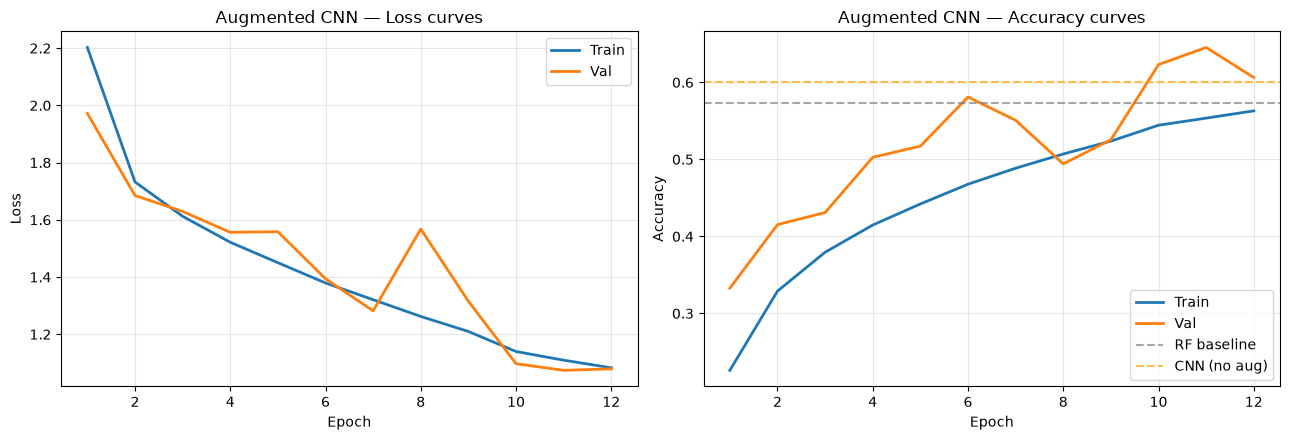

Saved to c:\Users\Constantine\Code\ml-project\report\cnn_augmented_training_curves.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = range(1, len(history_aug["train_loss"]) + 1)

axes[0].plot(epochs, history_aug["train_loss"], label="Train", linewidth=2)
axes[0].plot(epochs, history_aug["val_loss"], label="Val", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Augmented CNN — Loss curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history_aug["train_acc"], label="Train", linewidth=2)
axes[1].plot(epochs, history_aug["val_acc"], label="Val", linewidth=2)
axes[1].axhline(0.573, color="gray", linestyle="--", alpha=0.7, label="RF baseline")
axes[1].axhline(0.601, color="orange", linestyle="--", alpha=0.7, label="CNN (no aug)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Augmented CNN — Accuracy curves")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(REPORT_DIR / "cnn_augmented_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved to {REPORT_DIR / 'cnn_augmented_training_curves.png'}")

In [ ]:
_, _, rf_f1, _ = precision_recall_fscore_support(
    y_val_feat, y_val_pred_rf, labels=range(NUM_CLASSES), zero_division=0
)
_, _, cnn_f1, _ = precision_recall_fscore_support(
    y_val_true, y_val_pred, labels=range(NUM_CLASSES), zero_division=0
)
_, _, cnn_aug_f1, _ = precision_recall_fscore_support(
    y_val_true_aug, y_val_pred_aug, labels=range(NUM_CLASSES), zero_division=0
)

print(f"\n{'Category':<24} {'RF':>8} {'CNN':>8} {'CNN+aug':>10} {'Δ vs RF':>10}")
print("-" * 62)

for name, (a, b) in groups.items():
    rf_mean = rf_f1[a:b].mean()
    cnn_mean = cnn_f1[a:b].mean()
    cnn_aug_mean = cnn_aug_f1[a:b].mean()
    delta = cnn_aug_mean - rf_mean
    marker = " ←" if abs(delta) > 0.05 else ""
    print(f"{name:<24} {rf_mean:>8.3f} {cnn_mean:>8.3f} {cnn_aug_mean:>10.3f} {delta:>+10.3f}{marker}")

overall_rf = accuracy_score(y_val_feat, y_val_pred_rf)
overall_cnn = accuracy_score(y_val_true, y_val_pred)
overall_cnn_aug = accuracy_score(y_val_true_aug, y_val_pred_aug)
print("-" * 62)
print(f"{'Overall accuracy':<24} {overall_rf:>8.3f} {overall_cnn:>8.3f} {overall_cnn_aug:>10.3f} {overall_cnn_aug - overall_rf:>+10.3f}")